In [9]:
import os
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
import random

%matplotlib inline

# Set paths
json_path = "../data/datasets/fakeddit_subset/fakeddit_subset/training_data_fakeddit.jsonl"
image_dir = "../data/datasets/fakeddit_subset/fakeddit_subset/image_folder"

# Output dir
os.makedirs("../data/processed", exist_ok=True)


In [10]:
with open(json_path, "r") as f:
    lines = f.readlines()

print("Total JSON entries:", len(lines))
print("Example entry:\n", lines[0][:300])


Total JSON entries: 4000
Example entry:
 {"contents": [{"role": "user", "parts": [{"fileData": {"mimeType": "image/jpeg", "fileUri": "gs://my_trial_bucket_finetune/image_folder/9a46c1362ec06f0ffbd2578fa777ea8d.jpg"}}, {"text": "Title:\"he cut some tomatoes and put them in a bucket what happened days later made me so jealous\"\n\nis the pic


In [11]:
def extract_json_data(line):
    try:
        item = json.loads(line)
        user = item["contents"][0]
        model = item["contents"][1]
        
        # Extract text
        text = user["parts"][1]["text"]
        # Extract image name
        img_uri = user["parts"][0]["fileData"]["fileUri"]
        img_name = os.path.basename(img_uri)
        # Extract label (Yes=1 fake, No=0 real)
        label = 1 if model["parts"][0]["text"].strip().lower() == "yes" else 0
        
        return img_name, text, label
    except Exception as e:
        return None

parsed_data = []
for line in tqdm(lines, desc="Parsing JSON"):
    data = extract_json_data(line)
    if data:
        parsed_data.append(data)

print("Parsed samples:", len(parsed_data))


Parsing JSON:   0%|          | 0/4000 [00:00<?, ?it/s]

Parsing JSON: 100%|██████████| 4000/4000 [00:00<00:00, 62609.03it/s]

Parsed samples: 4000


In [12]:
available_images = set(os.listdir(image_dir))
df = pd.DataFrame(parsed_data, columns=["image_name", "text", "label"])
df["exists"] = df["image_name"].apply(lambda x: x in available_images)

# Keep only valid ones
df = df[df["exists"]].drop(columns=["exists"])
print("Valid samples with local images:", len(df))
df.head(3)


Valid samples with local images: 4000


,image_name,text,label
0,9a46c1362ec06f0ffbd2578fa777ea8d.jpg,"Title:""he cut some tomatoes and put them in a ...",1
1,18bb4fa9fd1dfc1fd318887c997a01d5.jpg,"Title:""crazy tennis face ripe for the photosho...",0
2,44ac90bced0683e03379f63adac4317a.jpg,"Title:""spicy vitamin water exists""\n\nis the p...",0


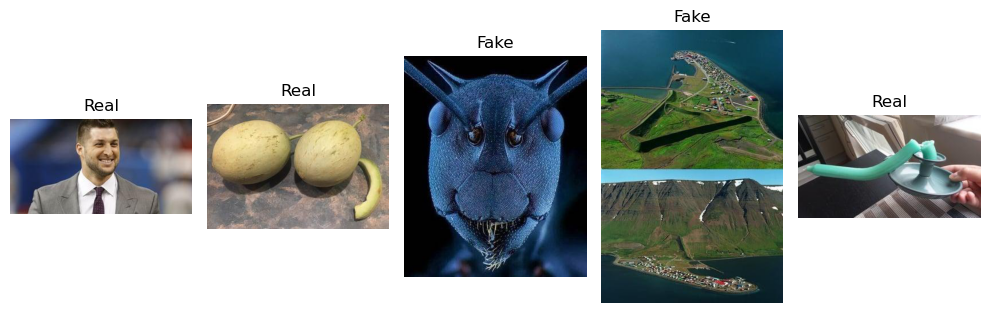

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

sample = df.sample(5, random_state=42)
plt.figure(figsize=(10,6))

for i, row in enumerate(sample.itertuples()):
    img_path = os.path.join(image_dir, row.image_name)
    img = mpimg.imread(img_path)
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Fake" if row.label==1 else "Real")
plt.tight_layout()
plt.show()

In [14]:
sample_size = 1000
if len(df) > sample_size:
    df = df.sample(sample_size, random_state=42).reset_index(drop=True)

df.to_csv("../data/processed/multimodal_dataset.csv", index=False)
print("Saved subset → ../data/processed/multimodal_dataset.csv")


Saved subset → ../data/processed/multimodal_dataset.csv
